In [1]:
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/titanic.zip'
extract_path = '/content/titanic'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Titanic dataset extracted successfully!")
print("Files:", os.listdir(extract_path))

Mounted at /content/drive
Titanic dataset extracted successfully!
Files: ['train.csv', 'test.csv', 'gender_submission.csv']


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/titanic/train.csv')

# Family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Whether passenger was travelling alone
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Extract title from name
df['Title'] = df['Name'].str.extract(r',\s*([^.]*)\.')[0].str.strip()

# Fare per person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

print("Feature Engineering Completed!")
display(df[['Name', 'FamilySize', 'IsAlone', 'Title', 'FarePerPerson']].head())

Feature Engineering Completed!


,Name,FamilySize,IsAlone,Title,FarePerPerson
0,"Braund, Mr. Owen Harris",2,0,Mr,3.62500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2,0,Mrs,35.64165
2,"Heikkinen, Miss. Laina",1,1,Miss,7.92500
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2,0,Mrs,26.55000
4,"Allen, Mr. William Henry",1,1,Mr,8.05000


In [3]:
print("Dataset Shape:", df.shape)

print("\nFamily Size Distribution:")
print(df['FamilySize'].value_counts().sort_index())

print("\nIs Alone:")
print(df['IsAlone'].value_counts())

print("\nTop Titles:")
print(df['Title'].value_counts().head(10))

print("\nNew Feature Statistics:")
display(df[['FamilySize', 'FarePerPerson']].describe())

Dataset Shape: (891, 16)

Family Size Distribution:
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

Is Alone:
IsAlone
1    537
0    354
Name: count, dtype: int64

Top Titles:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Dr          7
Rev         6
Col         2
Mlle        2
Major       2
Ms          1
Name: count, dtype: int64

New Feature Statistics:


,FamilySize,FarePerPerson
count,891.000000,891.000000
mean,1.904602,19.916375
std,1.613459,35.841257
min,1.000000,0.000000
25%,1.000000,7.250000
50%,1.000000,8.300000
75%,2.000000,23.666667
max,11.000000,512.329200


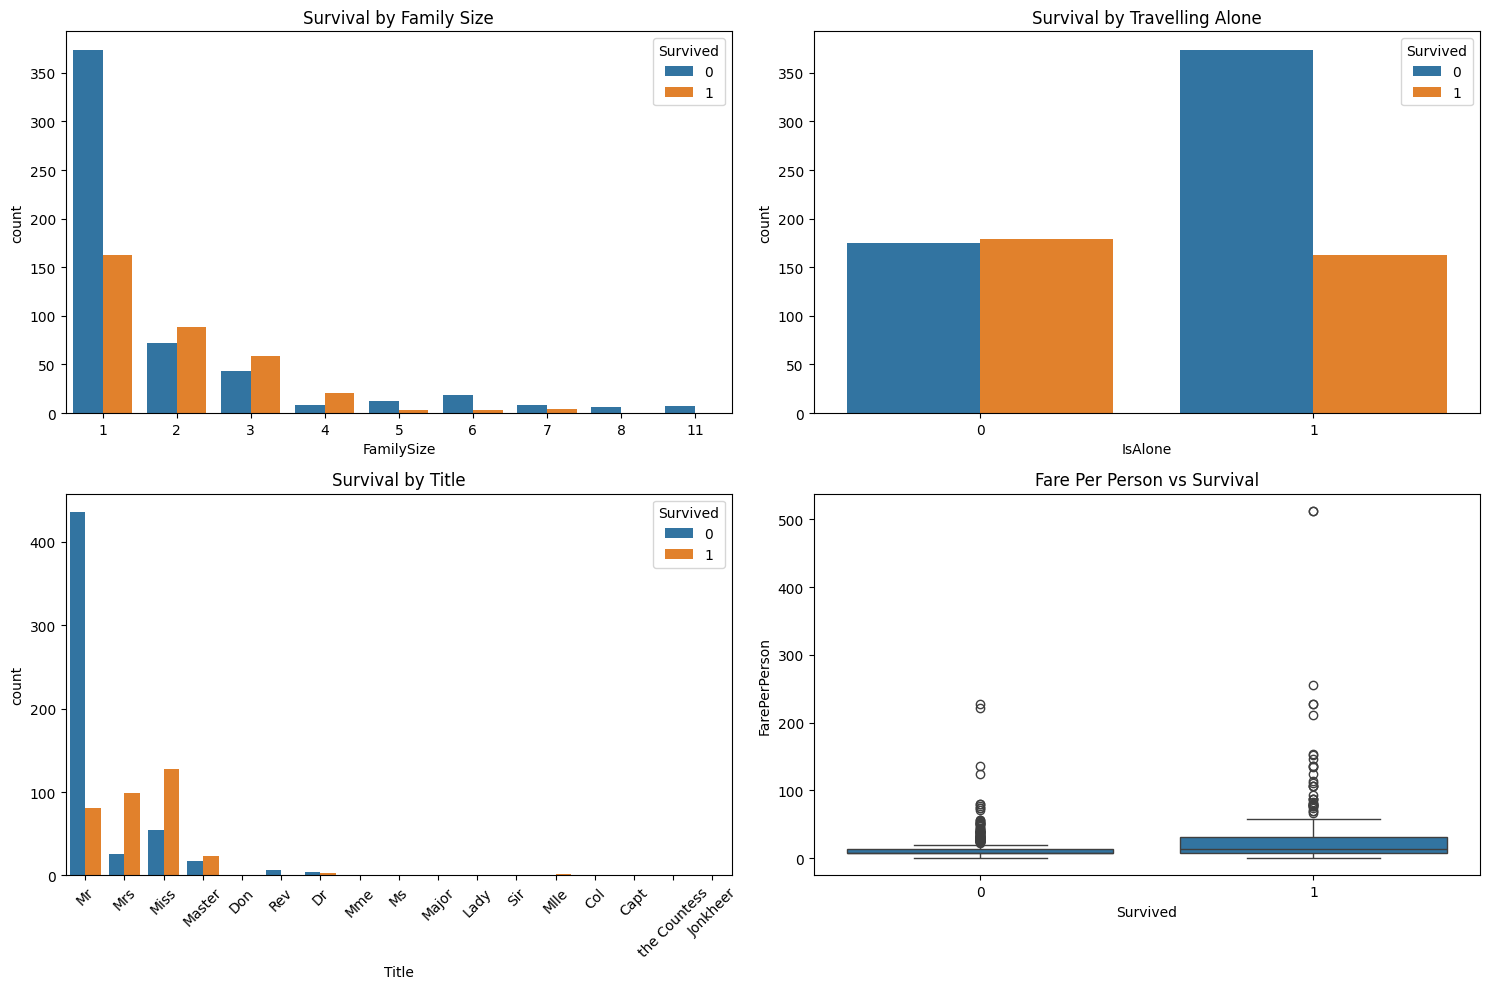

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.countplot(x='FamilySize', hue='Survived', data=df)
plt.title('Survival by Family Size')

plt.subplot(2, 2, 2)
sns.countplot(x='IsAlone', hue='Survived', data=df)
plt.title('Survival by Travelling Alone')

plt.subplot(2, 2, 3)
sns.countplot(x='Title', hue='Survived', data=df)
plt.xticks(rotation=45)
plt.title('Survival by Title')

plt.subplot(2, 2, 4)
sns.boxplot(x='Survived', y='FarePerPerson', data=df)
plt.title('Fare Per Person vs Survival')

plt.tight_layout()
plt.show()

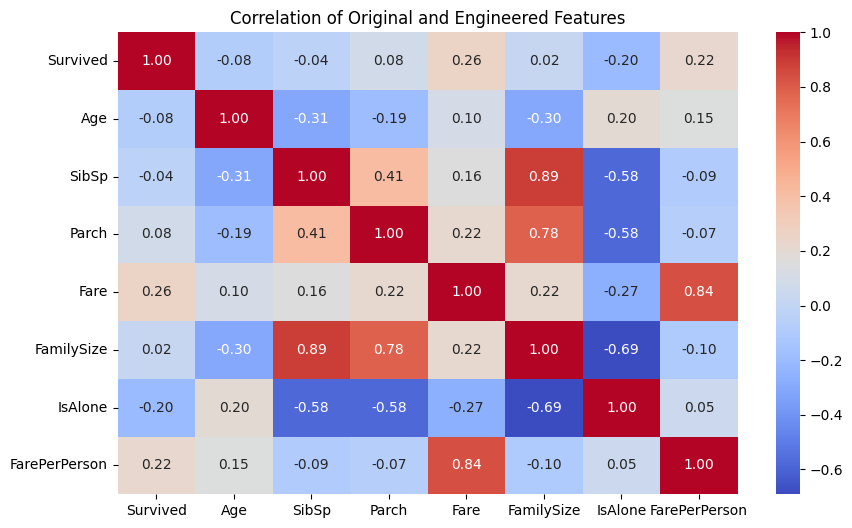

In [5]:
numeric_features = df[
    ['Survived', 'Age', 'SibSp', 'Parch',
     'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson']
]

plt.figure(figsize=(10, 6))

sns.heatmap(
    numeric_features.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation of Original and Engineered Features')
plt.show()

In [6]:
print("FEATURE ENGINEERING AND EDA COMPLETED")
print("=" * 45)

print("Original Features:", 12)
print("Final Features:", df.shape[1])

print("\nNew Features Created:")
print("1. FamilySize")
print("2. IsAlone")
print("3. Title")
print("4. FarePerPerson")

print("\nDataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

FEATURE ENGINEERING AND EDA COMPLETED
Original Features: 12
Final Features: 16

New Features Created:
1. FamilySize
2. IsAlone
3. Title
4. FarePerPerson

Dataset Shape: (891, 16)

Missing Values:
PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age              177
SibSp              0
Parch              0
Ticket             0
Fare               0
Cabin            687
Embarked           2
FamilySize         0
IsAlone            0
Title              0
FarePerPerson      0
dtype: int64
